# Bài toán phân cụm
Phân cụm các loài hoa Iris dựa trên dữ liệu từ thư viện Iris.
1. Chọn số cụm K thủ công
2. Chọn số cụm K tự động

## Import dữ liệu

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

RANDOM_STATE = 42          # co dinh de ket qua lap lai duoc giua cac lan chay

# 1. Tai du lieu Iris
iris = load_iris()
print(f"Kich thuoc du lieu day du (so hang, so cot): {iris.data.shape}")
print(iris.data[:10])

dai_hoa = iris.data[:, :2]   # chieu dai va chieu rong dai hoa
print("\nChieu dai va chieu rong dai hoa")
print(f"Kich thuoc: {dai_hoa.shape}")
print(dai_hoa[:10])

canh_hoa = iris.data[:, 2:4]  # chieu dai va chieu rong canh hoa

Kích thước của dữ liệu (số hàng, số cột): (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]

Chiều dài và chiều rộng của đài hoa
Kích thước của dữ liệu (số hàng, số cột): (150, 2)
[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]
 [5.4 3.9]
 [4.6 3.4]
 [5.  3.4]
 [4.4 2.9]
 [4.9 3.1]]


## Vẽ đồ thị phân bố

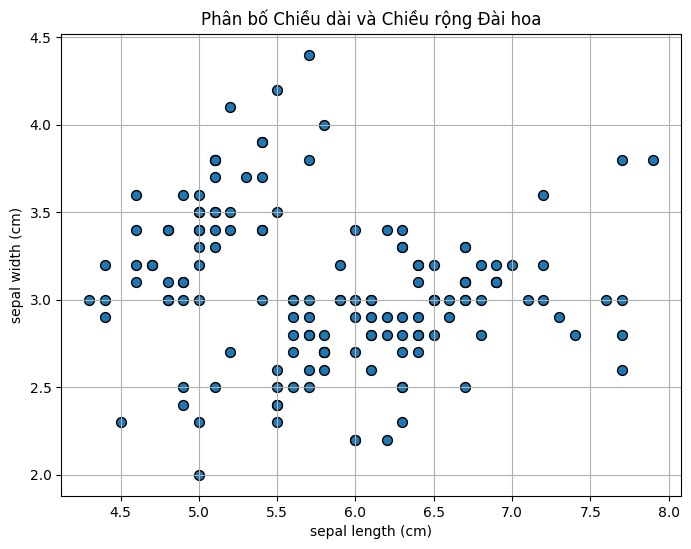

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(dai_hoa[:, 0], dai_hoa[:, 1], edgecolor='k', s=50)
plt.xlabel(iris.feature_names[0])   # 'sepal length (cm)'
plt.ylabel(iris.feature_names[1])   # 'sepal width (cm)'
plt.title('Phan bo chieu dai va chieu rong dai hoa')
plt.grid(True)
plt.show()

# Xác định số cụm (k) thủ công

## Chọn bộ dữ liệu để phân cụm

In [25]:
data = dai_hoa      # phan cum tren hai dac trung dai hoa

## Vẽ biểu đồ Elbow và Silhouete để chọn k

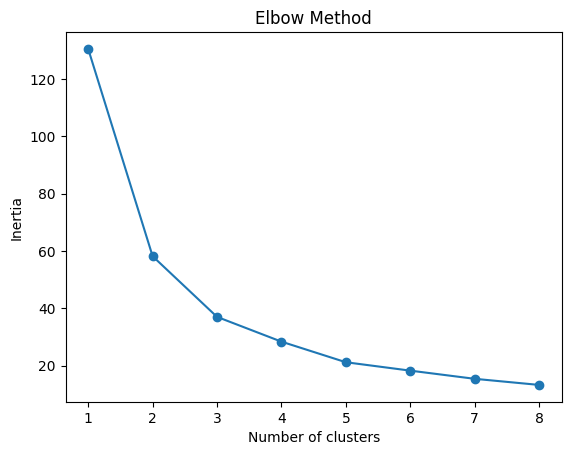

In [26]:
# Bieu do Elbow
inertia = []                      # tong binh phuong khoang cach toi tam cum
for k in range(1, 9):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto',
                    random_state=RANDOM_STATE).fit(data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('So cum k')
plt.ylabel('Inertia')
plt.xticks(range(1, 9))
plt.grid(True)
plt.show()

print("inertia:", np.round(inertia, 1))

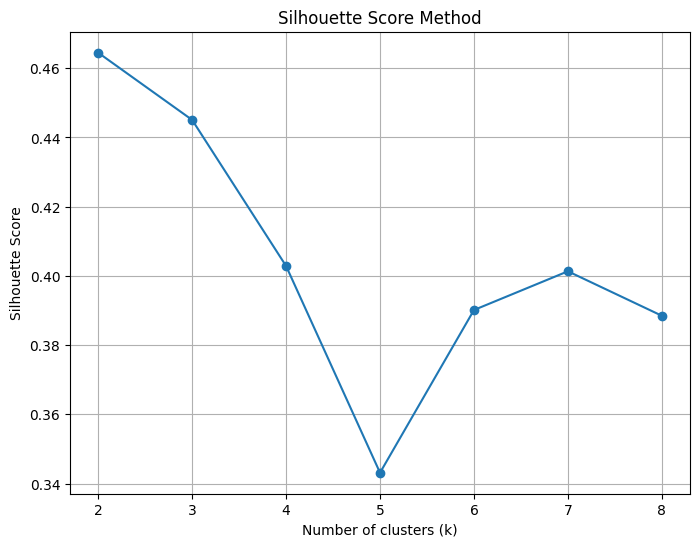

In [27]:
# Bieu do he so bong (silhouette)
from sklearn.metrics import silhouette_score

he_so_bong = []
for k in range(2, 9):             # he so bong khong dinh nghia voi k = 1
    nhan = KMeans(n_clusters=k, init='k-means++', n_init='auto',
                  random_state=RANDOM_STATE).fit_predict(data)
    he_so_bong.append(silhouette_score(data, nhan))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), he_so_bong, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('So cum k')
plt.ylabel('He so bong')
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

print("he so bong:", np.round(he_so_bong, 3))

## Phân cụm dùng KMeans

In [28]:
# Chon so cum thu cong
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto',
                random_state=RANDOM_STATE).fit(data)

df = pd.DataFrame(data, columns=iris.feature_names[:2])
df['Cluster'] = kmeans.labels_

print("Tam cum (thang do goc):")
for i, tam in enumerate(kmeans.cluster_centers_):
    print("  Cum %d: %.2f cm ; %.2f cm | %d mau"
          % (i, tam[0], tam[1], (kmeans.labels_ == i).sum()))

display(df.sample(10, random_state=RANDOM_STATE))

,sepal length (cm),sepal width (cm),Cluster
97,6.2,2.9,2
95,5.7,3.0,2
119,6.0,2.2,2
83,6.0,2.7,2
143,6.8,3.2,1
99,5.7,2.8,2
4,5.0,3.6,0
126,6.2,2.8,2
54,6.5,2.8,1
11,4.8,3.4,0


## Vẽ biểu đồ phân cụm

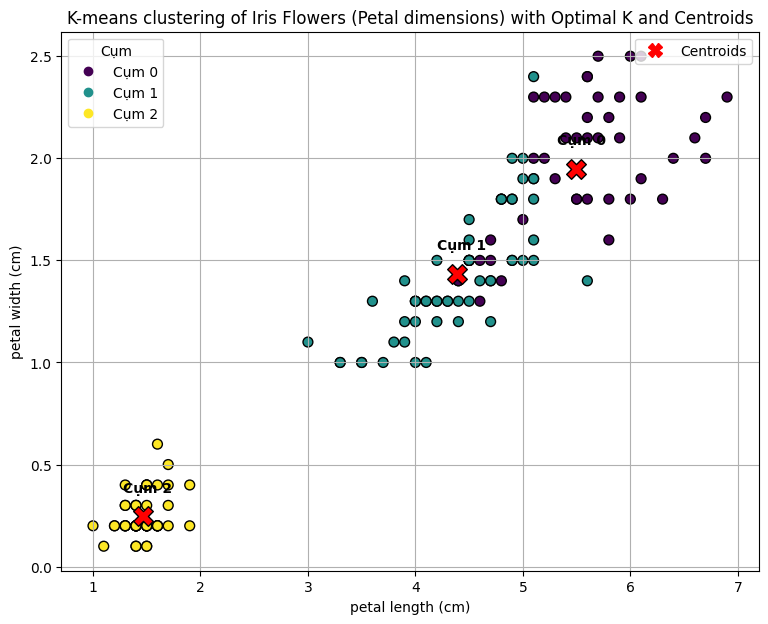

In [36]:
# Cung cac cum do, nhung nhin tren mat phang canh hoa
tam_canh_hoa = np.array([canh_hoa[df['Cluster'] == i].mean(axis=0)
                         for i in range(optimal_k)])

plt.figure(figsize=(9, 6))
for i in range(optimal_k):
    diem = canh_hoa[df['Cluster'] == i]
    plt.scatter(diem[:, 0], diem[:, 1], s=50, edgecolor='k',
                label=f'Cum {i}')
plt.scatter(tam_canh_hoa[:, 0], tam_canh_hoa[:, 1], marker='X', s=200,
            c='red', edgecolor='black', label='Trung binh cum')

plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title('Cac cum chia theo dai hoa, ve tren mat phang canh hoa')
plt.legend()
plt.grid(True)
plt.show()

# Doi chieu voi nhan loai that - chi dung de kiem chung
print(pd.crosstab(df['Cluster'], iris.target_names[iris.target]))

### Giải thích cụm trên biểu đồ đài hoa

*   **Cụm 0:** các bông có đài hoa dài nhất, chiều rộng trung bình.
*   **Cụm 1:** đài hoa dài trung bình, chiều rộng nhỏ nhất.
*   **Cụm 2:** đài hoa ngắn nhất nhưng chiều rộng lớn nhất.

Ba cụm được tách chủ yếu theo chiều dài đài hoa; ranh giới giữa cụm 0 và cụm 1 không rõ ràng.

### Giải thích cụm trên biểu đồ cánh hoa

Vẽ **chính các cụm đó** trên mặt phẳng cánh hoa cho thấy rõ hơn:

*   **Cụm 2** tách hẳn ra một góc với cánh hoa rất nhỏ — đúng loài `Iris setosa`, bảng đối chiếu cho thấy cụm này gom trọn cả 50 bông setosa.
*   **Cụm 0 và cụm 1** vẫn chồng lấn: hai loài `versicolor` và `virginica` bị trộn vào nhau.

Kết luận: hai đặc trưng đài hoa đủ để tách một loài, nhưng không đủ để tách ba loài. Chất lượng phân cụm phụ thuộc vào việc **chọn đặc trưng** nhiều hơn phụ thuộc vào thuật toán.

# Xác định số cụm (k) tự động

## Chọn bộ dữ liệu để phân cụm

In [30]:
data = dai_hoa      # phan cum tren hai dac trung dai hoa

## Tự động xác định số cụm (k) bằng Elbow

In [31]:
# Tu dong xac dinh so cum k bang phuong phap khuyu tay
inertia = []
max_k = 9
for k in range(1, max_k):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto',
                    random_state=RANDOM_STATE).fit(data)
    inertia.append(kmeans.inertia_)

x = np.arange(1, max_k)
y = np.array(inertia)

# Khoang cach tu moi diem toi day cung noi diem dau va diem cuoi.
# Tich co huong cua hai vector 2 chieu la mot so vo huong, tinh truc tiep
# de tranh canh bao deprecated cua np.cross trong NumPy 2.0.
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])
v = p2 - p1
khoang_cach = np.abs(v[0]*(p1[1] - y) - (p1[0] - x)*v[1]) / np.linalg.norm(v)

optimal_k = int(x[np.argmax(khoang_cach)])
print("Khoang cach toi day cung:", np.round(khoang_cach, 2))
print(f"So cum k theo khuyu tay tu dong: {optimal_k}")

Optimal number of clusters (k) determined by Elbow heuristic: 3


/tmp/ipykernel_2394/1650961370.py:29: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distance = np.abs(np.cross(p2 - p1, p3 - p1)) / np.linalg.norm(p2 - p1)


## Tự động xác định số cụm (k) bằng KneeLocator

In [32]:
# Tu dong xac dinh so cum k bang thu vien kneed
!pip install -q kneed
from kneed import KneeLocator

diem_gay = KneeLocator(list(x), list(y), S=1.0,
                       curve='convex', direction='decreasing')
optimal_k = diem_gay.elbow
print(f"So cum k theo KneeLocator: {optimal_k}")

Optimal number of clusters (k) determined by KneeLocator: 3


## Phân cụm với số k đã chọn

     Sepal Length (cm)  Sepal Width (cm)  Cluster
0                  5.1               3.5        2
1                  4.9               3.0        2
2                  4.7               3.2        2
3                  4.6               3.1        2
4                  5.0               3.6        2
..                 ...               ...      ...
145                6.7               3.0        0
146                6.3               2.5        1
147                6.5               3.0        0
148                6.2               3.4        0
149                5.9               3.0        1

[150 rows x 3 columns]


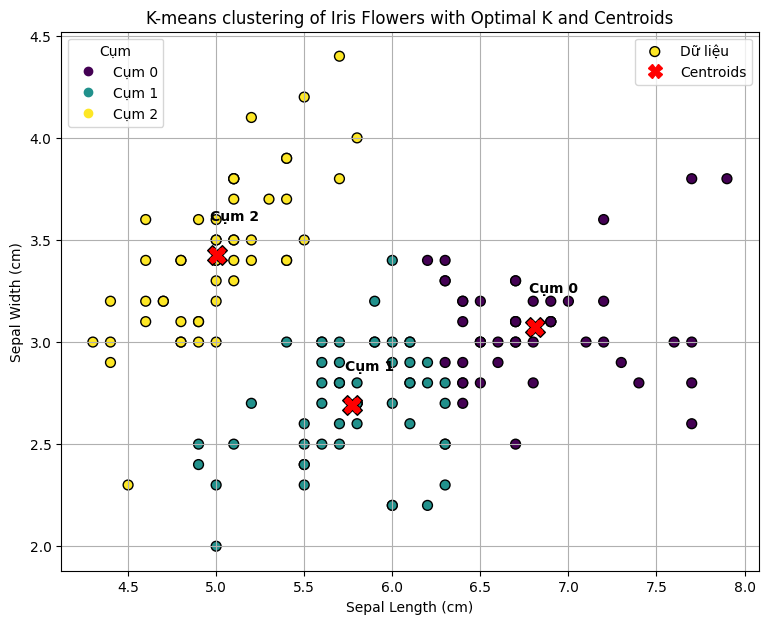

In [35]:
# K-means voi so cum da chon o buoc tren
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init='auto',
                random_state=RANDOM_STATE).fit(data)

df = pd.DataFrame(data, columns=['Sepal Length (cm)', 'Sepal Width (cm)'])
df['Cluster'] = kmeans.labels_
tam_cum = kmeans.cluster_centers_

print("Tam cum:")
for i, tam in enumerate(tam_cum):
    print("  Cum %d: %.2f cm ; %.2f cm | %d mau"
          % (i, tam[0], tam[1], (kmeans.labels_ == i).sum()))
print()
print(df.head())

plt.figure(figsize=(9, 6))
for i in range(optimal_k):
    diem = data[kmeans.labels_ == i]
    plt.scatter(diem[:, 0], diem[:, 1], s=50, edgecolor='k', label=f'Cum {i}')
plt.scatter(tam_cum[:, 0], tam_cum[:, 1], marker='X', s=200, c='red',
            edgecolor='black', label='Tam cum')
for i, tam in enumerate(tam_cum):
    plt.annotate(f'Cum {i}', (tam[0], tam[1]), textcoords='offset points',
                 xytext=(0, 14), ha='center', fontsize=10, weight='bold')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title(f'K-means tren du lieu Iris voi k = {optimal_k}')
plt.legend()
plt.grid(True)
plt.show()